## Indian Bird Classification - CNN

India is a country known for its rich biodiversity and diverse ecosystems. This provides a suitable environment for different bird species to live. Birds in India include both local and migratory species and it is important to monitor, protect and research these species. Observing and classifying birds using traditional methods can be time-consuming and challenging. Therefore, artificial intelligence and deep learning techniques have become an effective tool for automatically identifying bird species. Convolutional Neural Networks (CNN), in particular, are used with high success rates in image processing and classification tasks. In this project, we will develop a CNN model related to bird species in India.

<img src='bird.jpg' width=450 >

<a href='https://www.kaggle.com/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images' target=_blank>You can find the data file here</a>

In [ ]:
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = '25-indian-bird-species-with-226k-images:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F2964687%2F5868890%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240919%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240919T231419Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D4a1263340fe6a104c1f347258be10c840bcf96648262f609f6ba05084954d57b0f8369e85e22c7ed6bb9bfbcca7174b81d59dce6ac864ddc892437adb16014378004491d31771a6f3573101ffb0d9f5981ae2dc864f1da679574d431f78147139c6e64eed57a9fa231a1ca4e3ee5f18fa334cd9139e5bb94d261bb23b521b4d4a7db9cd1e8c89aa627c069948f9659eb0cc4dea0cf8dcba6e80a60223092c64d02fce3e480e6cce592b6dea3426a56c8f1807cfdb36b0b0d219b9b863dcccc3c8466189780e8661dbee9d697cb5e69e5ce5e35312134f2c0627c4b57c5f31f366e8eb37c9dec60b3a7a66ec73078cea69c8615c649756d04a13a925e15edb528'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 10021956459 bytes downloaded
Downloaded and uncompressed: 25-indian-bird-species-with-226k-images
Data source import complete.


### Import Libraries

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Input, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from IPython.display import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import save_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import warnings
warnings.filterwarnings('ignore')

### Determine the File Path

In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Görüntülenen çıkış son 5000 satıra kısaltıldı.
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML250080391.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML192614371.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML70956461.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML349964381.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML55334551.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML218629601.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML99552261.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML75705131.jpg
/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/M

In [54]:
print(os.listdir('/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set'))

['Hoopoe', 'Cattle Egret', 'Gray Wagtail', 'House Crow', 'White-Breasted Kingfisher', 'Common Rosefinch', 'Sarus Crane', 'Northern Lapwing', 'Coppersmith Barbet', 'Forest Wagtail', 'White Wagtail', 'Brown-Headed Barbet', 'Ruddy Shelduck', 'Asian Green Bee-Eater', 'White-Breasted Waterhen', 'Common Tailorbird', 'Indian Grey Hornbill', 'Indian Roller', 'Rufous Treepie', 'Common Myna', 'Jungle Babbler', 'Indian Pitta', 'Red-Wattled Lapwing', 'Indian Peacock', 'Common Kingfisher']


### Reading the pictures and labels

In [55]:
labels=['Indian Roller', 'White-Breasted Waterhen', 'Indian Grey Hornbill', 'Common Myna', 'Rufous Treepie',
        'Cattle Egret', 'House Crow', 'Ruddy Shelduck', 'Gray Wagtail', 'Forest Wagtail', 'Common Tailorbird',
        'Sarus Crane', 'White Wagtail', 'Jungle Babbler', 'Hoopoe', 'Coppersmith Barbet', 'Common Kingfisher',
        'Brown-Headed Barbet', 'Indian Peacock', 'Asian Green Bee-Eater', 'Indian Pitta', 'Red-Wattled Lapwing',
        'Northern Lapwing', 'White-Breasted Kingfisher', 'Common Rosefinch']

img_path='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/'

In [56]:
img_list=[]
label_list=[]

for label in labels:
    for img_file in os.listdir(img_path+label):
            img_list.append(img_path+label+'/'+img_file)
            label_list.append(label)

In [57]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [58]:
df.sample(5)

,img,label
15206,/kaggle/input/25-indian-bird-species-with-226k...,Common Kingfisher
12144,/kaggle/input/25-indian-bird-species-with-226k...,Jungle Babbler
12496,/kaggle/input/25-indian-bird-species-with-226k...,Jungle Babbler
11095,/kaggle/input/25-indian-bird-species-with-226k...,White Wagtail
10116,/kaggle/input/25-indian-bird-species-with-226k...,Sarus Crane


In [59]:
df.tail()

,img,label
22615,/kaggle/input/25-indian-bird-species-with-226k...,Common Rosefinch
22616,/kaggle/input/25-indian-bird-species-with-226k...,Common Rosefinch
22617,/kaggle/input/25-indian-bird-species-with-226k...,Common Rosefinch
22618,/kaggle/input/25-indian-bird-species-with-226k...,Common Rosefinch
22619,/kaggle/input/25-indian-bird-species-with-226k...,Common Rosefinch


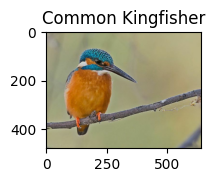

In [60]:
p='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Kingfisher/ML379744501.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Common Kingfisher')
plt.show()

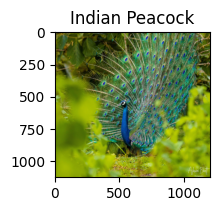

In [61]:
p='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Indian Peacock/ML358263901.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Indian Peacock')
plt.show()

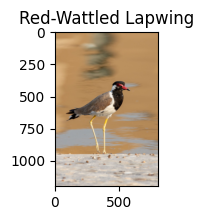

In [62]:
p='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Red-Wattled Lapwing/ML168021931.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Red-Wattled Lapwing')
plt.show()

### Label Encoding

In [63]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['encoded_labels'] = le.fit_transform(df['label'])

In [64]:
df.sample(5)

,img,label,encoded_labels
15955,/kaggle/input/25-indian-bird-species-with-226k...,Brown-Headed Barbet,1
4808,/kaggle/input/25-indian-bird-species-with-226k...,Cattle Egret,2
11236,/kaggle/input/25-indian-bird-species-with-226k...,White Wagtail,22
17803,/kaggle/input/25-indian-bird-species-with-226k...,Asian Green Bee-Eater,0
316,/kaggle/input/25-indian-bird-species-with-226k...,Indian Roller,15


In [65]:
x=[]

for img_path in df['img']:
    try:
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (32, 32))
            img = img / 255.0
            x.append(img)
        else:
            print(f"Unable to read image: {img_path}")
    except Exception as e:
        print(f"Error processing image: {img_path}")
        print(e)

Unable to read image: /kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Ruddy Shelduck/ML220226881.jpg
Unable to read image: /kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Sarus Crane/ML113680271.jpg
Unable to read image: /kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Red-Wattled Lapwing/ML48543381.jpg


### Modelling

In [66]:
x=np.array(x)

In [67]:
y=df['encoded_labels']

In [68]:
print(len(x))
print(len(y))

22617
22620


In [69]:
y = y[:len(x)]

In [70]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [71]:
model=Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128))
model.add(Dropout(0.2))
model.add(Dense(25,activation='softmax'))
early_stopping=EarlyStopping(monitor='val_accuracy', patience=10, verbose=1)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [72]:
history=model.fit(x_train,y_train,epochs=25,verbose=1,validation_data=(x_test,y_test),callbacks=[early_stopping])

Epoch 1/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.1337 - loss: 2.9889 - val_accuracy: 0.3278 - val_loss: 2.3385
Epoch 2/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.3664 - loss: 2.2108 - val_accuracy: 0.4401 - val_loss: 1.9638
Epoch 3/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.4648 - loss: 1.8431 - val_accuracy: 0.4943 - val_loss: 1.7608
Epoch 4/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.5416 - loss: 1.5950 - val_accuracy: 0.5115 - val_loss: 1.7521
Epoch 5/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.5820 - loss: 1.4199 - val_accuracy: 0.5172 - val_loss: 1.6977
Epoch 6/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.6267 - loss: 1.2626 - val_accuracy: 0.5062 - val_loss: 1.8165
Epoch 7/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.6637 - loss: 1.1503 - val_accuracy: 0.5166 - val_loss: 1.7489
Epoch 8/25
566/566 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - accuracy: 0.6962 - loss: 1.0326 - 

In [73]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 952,973 (3.64 MB)

 Trainable params: 317,657 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 635,316 (2.42 MB)

In [74]:
loss,accuracy=model.evaluate(x_test, y_test)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5047 - loss: 2.7327
Test Loss: 2.8078420162200928
Test Accuracy: 0.5066313147544861


In [75]:
pred=model.predict(x_test)

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


In [76]:
confusion_matrix(y_test,np.argmax(pred,axis=1))

array([[117,   4,   2,   2,   1,   5,   4,   7,   5,   4,   4,   2,   1,
          0,   5,   2,   1,   0,   0,   1,   2,   3,   2,   0,   2],
       [  7,  74,   0,   1,   4,   9,   7,  15,   8,   1,   3,   5,  12,
          4,   4,   6,   4,   0,   1,   2,  11,   2,   0,   4,   6],
       [  0,   2, 116,   0,   2,   4,   2,   0,   4,   2,   1,   2,   1,
          2,   0,   5,   8,   0,   1,   8,   2,   7,   6,   2,   5],
       [  0,   1,   2, 136,   1,   4,   1,   4,   2,   0,   2,   1,   0,
          8,   9,   5,   1,   1,   0,   7,   4,   2,   2,   4,   0],
       [  2,   3,   0,   0, 122,   3,   2,   5,   6,   2,   4,  15,   1,
          5,   5,   0,   3,   4,   5,   2,   9,   2,   2,   2,   5],
       [  3,  11,   2,   5,   9,  61,  10,  10,   3,   1,  19,   1,   6,
          0,   1,   9,   5,   1,   1,   1,   1,   5,   3,   7,   2],
       [  2,  11,   3,   2,   3,   6,  47,  10,  16,   8,   3,   2,   8,
          3,  13,   4,  11,   1,   1,   4,   9,   6,   1,   0,   5],
      

In [77]:
print(classification_report(y_test, np.argmax(pred,axis=1)))

              precision    recall  f1-score   support

           0       0.77      0.66      0.71       176
           1       0.40      0.39      0.39       190
           2       0.74      0.64      0.68       182
           3       0.70      0.69      0.70       197
           4       0.52      0.58      0.55       209
           5       0.36      0.34      0.35       177
           6       0.48      0.26      0.34       179
           7       0.32      0.30      0.31       148
           8       0.40      0.61      0.48       195
           9       0.60      0.50      0.54       190
          10       0.47      0.65      0.54       184
          11       0.52      0.51      0.52       206
          12       0.45      0.34      0.39       190
          13       0.49      0.61      0.54       175
          14       0.47      0.62      0.53       123
          15       0.49      0.50      0.49       175
          16       0.42      0.28      0.33       180
          17       0.49    

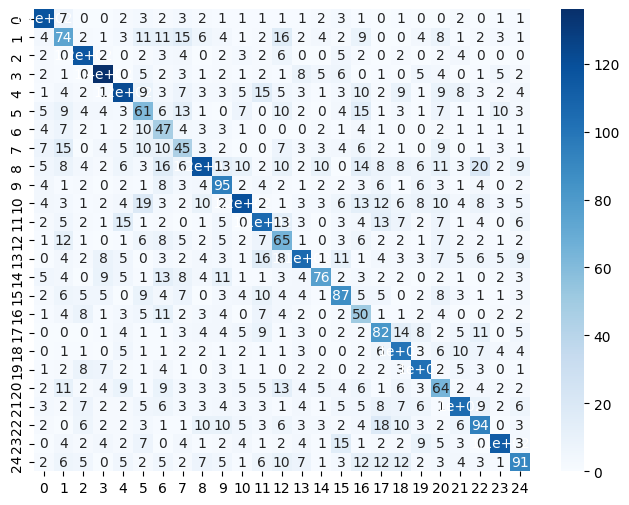

In [92]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(np.argmax(pred,axis=1), y_test)
#normalized_cm=cm / cm.sum()
sns.heatmap(cm, annot=True, cmap='Blues',annot_kws={"size": 10});

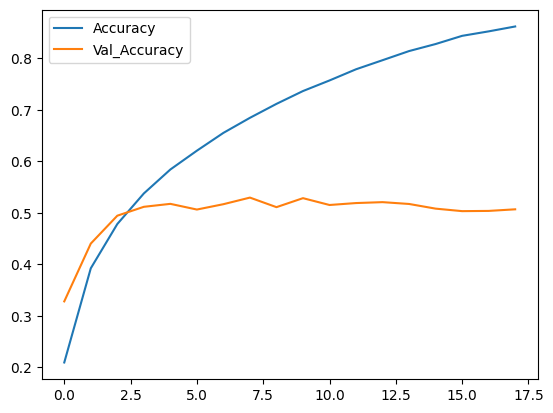

In [84]:
plt.plot(history.history['accuracy'],label='Accuracy')
plt.plot(history.history['val_accuracy'],label='Val_Accuracy')
plt.legend()

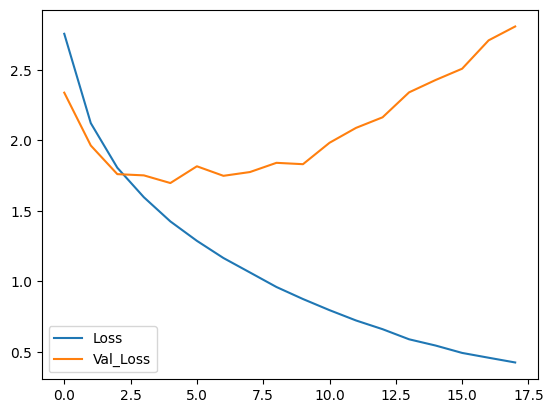

In [85]:
plt.plot(history.history['loss'],label='Loss')
plt.plot(history.history['val_loss'],label='Val_Loss')
plt.legend();

In [93]:
model.save('bird_model.h5')

## Transfer Learning

In [35]:
data_dir='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set'
img_width,img_height=32,32

train_datagen=ImageDataGenerator(rescale=1/255,validation_split=.20)
train_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_height),
                                class_mode='categorical', subset='training')

test_datagen=ImageDataGenerator(rescale=1/255)
test_datagenerator=train_datagen.flow_from_directory(directory=data_dir,target_size=(img_width,img_height),
                                class_mode='categorical', subset='validation')

base_model=VGG16(weights='imagenet', input_shape=(img_width,img_height,3),include_top=False)

model=Sequential()

model.add(base_model)
for layer in base_model.layers:
    layer.trainable=False

model.add(Flatten())
model.add(Dense(1024,activation='relu'))
model.add(Dense(25,activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train_datagenerator,epochs=15,validation_data=test_datagenerator)

Found 18106 images belonging to 25 classes.
Found 4514 images belonging to 25 classes.
Epoch 1/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 673s 1s/step - accuracy: 0.1831 - loss: 2.7923 - val_accuracy: 0.2607 - val_loss: 2.4621
Epoch 2/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.2922 - loss: 2.3678 - val_accuracy: 0.2785 - val_loss: 2.4060
Epoch 3/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 660s 1s/step - accuracy: 0.3284 - loss: 2.2226 - val_accuracy: 0.2913 - val_loss: 2.4027
Epoch 4/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 648s 1s/step - accuracy: 0.3552 - loss: 2.1235 - val_accuracy: 0.2918 - val_loss: 2.3827
Epoch 5/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 693s 1s/step - accuracy: 0.3814 - loss: 2.0321 - val_accuracy: 0.2873 - val_loss: 2.3897
Epoch 6/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 675s 1s/step - accuracy: 0.4186 - loss: 1.9113 - val_accuracy: 0.2904 - val_loss: 2.4301
Epoch 7/15
566/566 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.4361 - loss: 1.8503 - val_accuracy: 0.2966 - val_loss: 2.4176
Epoch 8/15

In [36]:
test_loss, test_acc=model.evaluate(test_datagenerator, verbose=2)
print('Test Accuracy:', test_acc)
print('Test Loss:', test_loss)

142/142 - 149s - 1s/step - accuracy: 0.3033 - loss: 2.7919
Test Accuracy: 0.30327868461608887
Test Loss: 2.791886329650879


In [37]:
model.save('bird.keras')

### Predict the Images

In [38]:
img=image.load_img('/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML204036251.jpg', target_size=(224,224))
img=image.img_to_array(img)
img=np.expand_dims(img, axis=0)

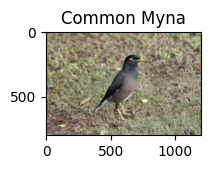

In [42]:
p='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Common Myna/ML204036251.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Common Myna')
plt.show()

In [39]:
model=VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [40]:
pred=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [41]:
decode_predictions(pred, top=1)
#The model guessed it as partridge, we can consider it correct

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n01807496', 'partridge', 0.33255294)]]

In [43]:
img=image.load_img('/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Jungle Babbler/ML231896771.jpg', target_size=(224,224))
img=image.img_to_array(img)
img=np.expand_dims(img, axis=0)

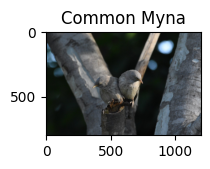

In [47]:
p='/kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set/Jungle Babbler/ML231896771.jpg'
plt.figure(figsize=(2,2))
plt.imshow(plt.imread(p))
plt.title('Common Myna')
plt.show()

In [44]:
model=VGG16(weights='imagenet')

In [45]:
pred=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [46]:
decode_predictions(pred, top=1)
#The picture predicted by the model is similar to the picture we gave. We can also consider this to be correct.

[[('n01534433', 'junco', 0.31017295)]]

## Summary

In this study, a CNN model was developed to identify bird species in India. The model was trained using a large dataset and optimized to identify images of different bird species. Data augmentation techniques were used during the training process to increase the generalization ability of the model. The results obtained showed that the model can classify different bird species with high accuracy. This study can contribute to bird monitoring and conservation efforts and help develop strategies for protecting biodiversity. In addition, the use of such technologies can inspire future research to monitor and protect wildlife.
In addition to training the model ourselves, we also used transfer learning packages while doing this project.
Although our success rate in the CNN model we developed was 50 percent, our model generally predicted the images we provided correctly.